In [36]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import timedelta

In [37]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [38]:
# Loading the data
llama_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_for_analysis.csv'))
df = pd.merge(
    comments_df, 
    llama_df[['comment_id', 'category', 'sentiment', 'confidence']], 
    on='comment_id', 
    how='inner')
df['comment_date'] = pd.to_datetime(df['comment_date'])
df.head()

,comment_id,parent_id,parent_text,text_preprocessed,video_title,video_context,video_id,comment_date,author_hash,days_from_genai_announcement,...,mentions_genai,mentions_business_model,mentions_game,likes,like_count_log,is_spike,z_score,category,sentiment,confidence
0,UgzLPJdZudI_r4we6c94AaABAg,NaN,NaN,Good choice of music,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:58:59,a866cdf8b46bef61d38e39e66a5beed117447786cc3a65...,-887,...,False,False,False,13,2.639057,False,NaN,Game_Related,Pos,0.90
1,UgyAUoHvzWPWW5jVv994AaABAg,NaN,NaN,this looks VERY fun,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:18,5f3f2b5524e8a6c69e3d960a00e26fb58fd4e70c490b16...,-887,...,False,False,False,782,6.663133,False,NaN,Game_Related,Pos,0.90
2,UgzwutSd2BKZ6h-6dRF4AaABAg,NaN,NaN,these graphics are sick!,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:37,93edc8fe622d6884c56b40ed55a8df4d8233ba69c46f71...,-887,...,False,False,True,3,1.386294,False,NaN,Game_Related,Pos,0.95
3,UgzlrEdJ-IeAuox6BLJ4AaABAg,NaN,NaN,"Ok, Arc Raiders....I see you",Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:48,9451ccfd3f4589dd62a33ec55593cc4694d5f1d924008a...,-887,...,False,False,True,6,1.945910,False,NaN,Game_Related,Neu,0.60
4,UgwcSGsGzi8y4_ynAhh4AaABAg,NaN,NaN,came here to shazam the song. The trailer is p...,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:58,8a4e74825f2dde5179ec5faf2f63728a4b3335f29919ff...,-887,...,False,False,True,3,1.386294,False,NaN,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182552 entries, 0 to 182551
Data columns (total 24 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   comment_id                       182552 non-null  str           
 1   parent_id                        40093 non-null   str           
 2   parent_text                      40092 non-null   str           
 3   text_preprocessed                182552 non-null  str           
 4   video_title                      182552 non-null  str           
 5   video_context                    170928 non-null  str           
 6   video_id                         182552 non-null  str           
 7   comment_date                     182552 non-null  datetime64[us]
 8   author_hash                      182552 non-null  str           
 9   days_from_genai_announcement     182552 non-null  int64         
 10  days_from_business_model_change  182552 non-null  int64

In [40]:
# =============================================================================
# 1. MATHEMATICAL FUNCTIONS
# =============================================================================

def decay_function(t, s0, lam):
    """Standard exponential decay formula: S(t) = s0 * e^(-lambda * t)"""
    return s0 * np.exp(-lam * t)

def fit_exponential_decay(daily_df, label="Group"):
    """
    Identifies the peak, fits the decay curve for the following 60 days,
    and calculates the Half-Life.
    """
    # 1. Identify peak volume date
    peak_idx = daily_df['volume'].idxmax()
    peak_date = daily_df.loc[peak_idx, 'comment_date']
    
    # 2. Filter for 60 days post-peak
    df_fit = daily_df[daily_df['comment_date'] >= peak_date].head(60).copy()
    df_fit['days'] = (df_fit['comment_date'] - peak_date).dt.days
    
    x_data = df_fit['days'].values
    y_data = df_fit['volume'].values
    
    try:
        # Initial guess: s0 = peak volume, lambda = 0.1
        popt, _ = curve_fit(decay_function, x_data, y_data, p0=[y_data[0], 0.1])
        s0_fit, lam_fit = popt
        half_life = np.log(2) / lam_fit
        
        # Prepare fit line for plotting
        fit_dates = [peak_date + timedelta(days=int(d)) for d in x_data]
        fit_values = decay_function(x_data, *popt)
        
        return {
            'peak_date': peak_date,
            'half_life': half_life,
            'decay_constant': lam_fit,
            'fit_dates': fit_dates,
            'fit_values': fit_values
        }
    except Exception as e:
        print(f"Could not fit decay for {label}: {e}")
        return None

In [41]:
# =============================================================================
# 2. DATA PROCESSING
# =============================================================================

# Map sentiment to numeric scores for weighting
sentiment_map = {'Pos': 1, 'Neu': 0, 'Neg': -1}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Define Research Groups
# Group A: General Game Discourse
game_cats = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related']
df_game = df[df['category'].isin(game_cats)].copy()

# Group B: Isolated AI Voice Controversy
df_ai = df[df['category'] == 'AI_Voice_Related'].copy()

# Aggregate Daily Volume and Mean Sentiment
def get_daily_stats(df_subset):
    return df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sentiment=('sentiment_score', 'mean')
    ).reset_index().rename(columns={'index': 'comment_date'})

daily_game = get_daily_stats(df_game)
daily_ai = get_daily_stats(df_ai)

# Ensure date column is datetime for plotting
daily_game['comment_date'] = pd.to_datetime(daily_game['comment_date'])
daily_ai['comment_date'] = pd.to_datetime(daily_ai['comment_date'])

# Run Mathematical Fits
game_results = fit_exponential_decay(daily_game, "General Game")
ai_results = fit_exponential_decay(daily_ai, "AI Controversy")

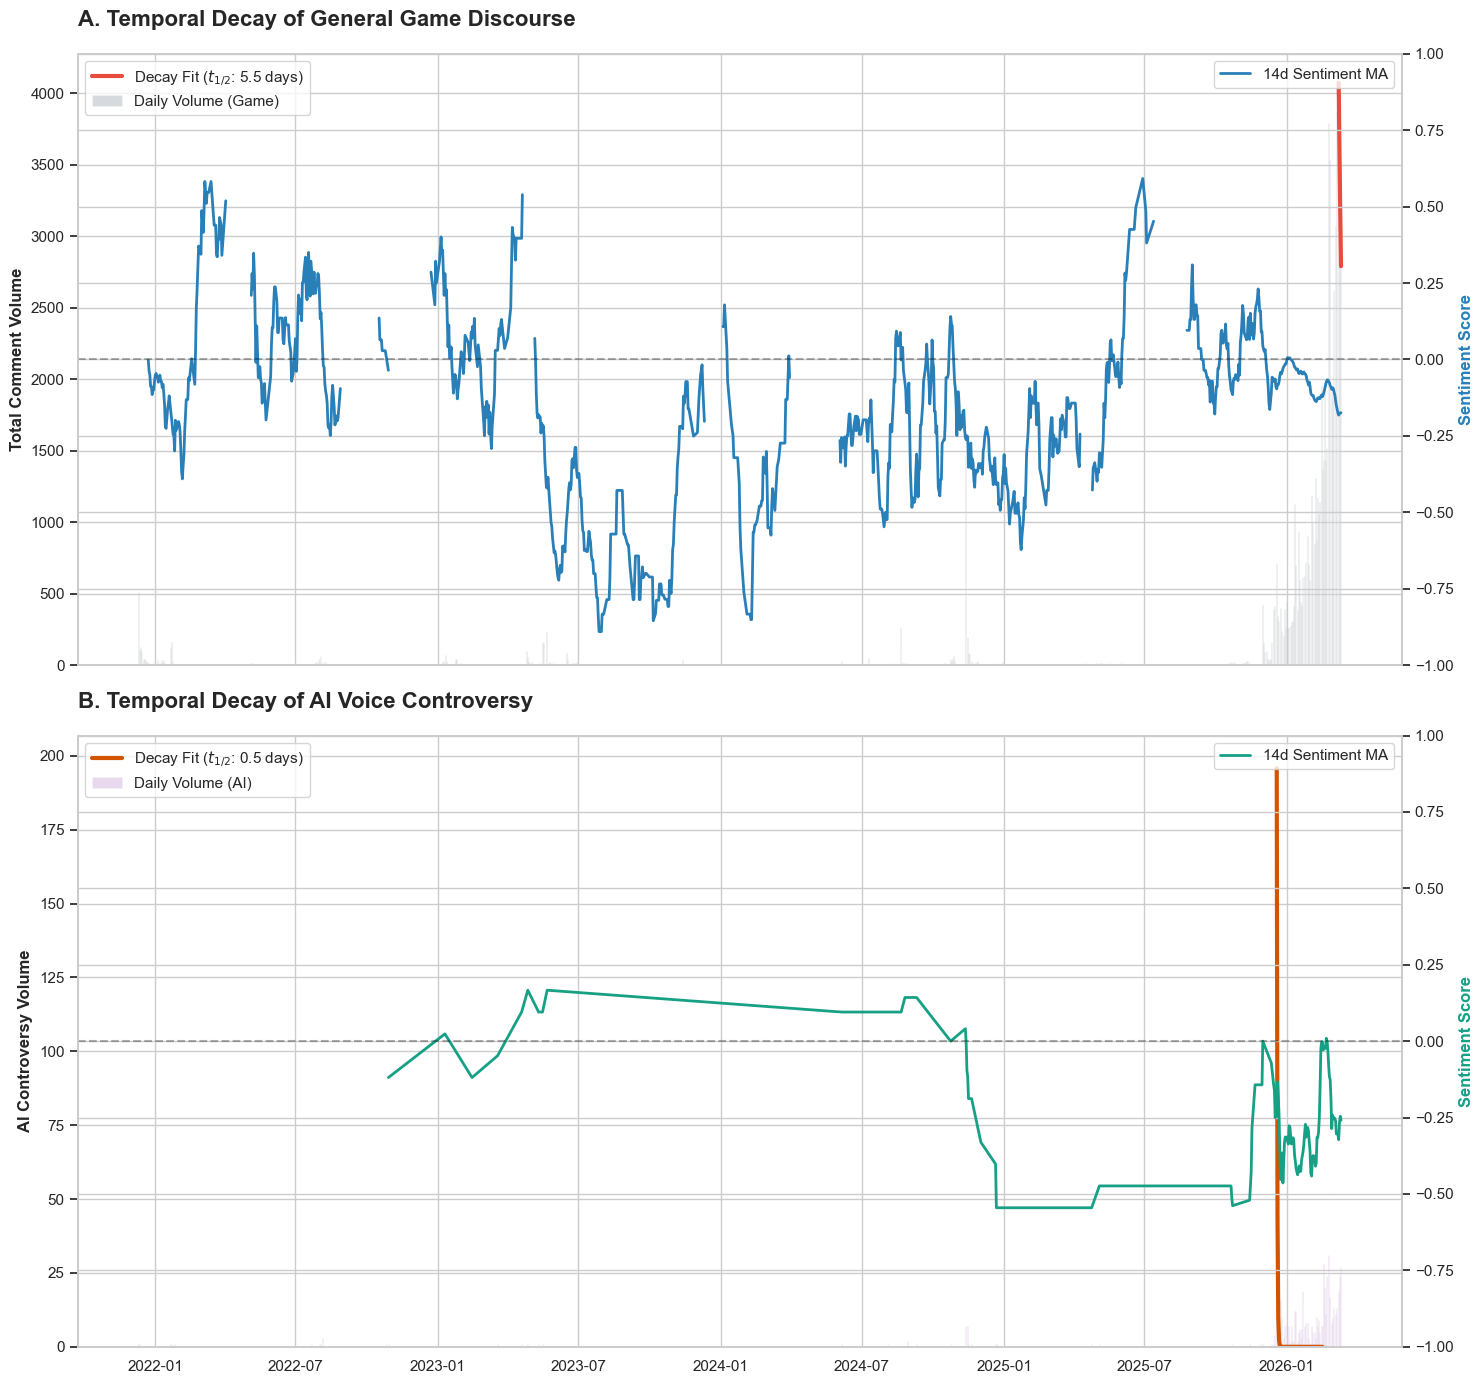

FINAL ANALYSIS RESULTS
GAME DISCOURSE  | Peak: 2026-03-09 | Half-Life: 5.50 days
AI CONTROVERSY  | Peak: 2025-12-19 | Half-Life: 0.46 days


In [42]:
# =============================================================================
# 3. VISUALIZATION
# =============================================================================

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)

# --- PLOT 1: GENERAL GAME DISCOURSE ---
# Volume Bars
ax1.bar(daily_game['comment_date'], daily_game['volume'], color='#34495E', alpha=0.2, label='Daily Volume (Game)')
# Decay Fit Line
if game_results:
    ax1.plot(game_results['fit_dates'], game_results['fit_values'], color='#E74C3C', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {game_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax1_s = ax1.twinx()
ax1_s.plot(daily_game['comment_date'], daily_game['sentiment'].rolling(14).mean(), color='#2980B9', linewidth=2, label='14d Sentiment MA')
ax1_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax1_s.set_ylim(-1, 1)

# Formatting
ax1.set_title("A. Temporal Decay of General Game Discourse", loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel("Total Comment Volume", fontsize=12, fontweight='bold')
ax1_s.set_ylabel("Sentiment Score", color='#2980B9', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1_s.legend(loc='upper right', frameon=True)

# --- PLOT 2: AI VOICE CONTROVERSY ---
# Volume Bars
ax2.bar(daily_ai['comment_date'], daily_ai['volume'], color='#8E44AD', alpha=0.2, label='Daily Volume (AI)')
# Decay Fit Line
if ai_results:
    ax2.plot(ai_results['fit_dates'], ai_results['fit_values'], color='#D35400', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {ai_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax2_s = ax2.twinx()
ax2_s.plot(daily_ai['comment_date'], daily_ai['sentiment'].rolling(14).mean(), color='#16A085', linewidth=2, label='14d Sentiment MA')
ax2_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax2_s.set_ylim(-1, 1)

# Formatting
ax2.set_title("B. Temporal Decay of AI Voice Controversy", loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel("AI Controversy Volume", fontsize=12, fontweight='bold')
ax2_s.set_ylabel("Sentiment Score", color='#16A085', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)
ax2_s.legend(loc='upper right', frameon=True)

# Global Cleanup
plt.xlabel("Timeline (2024 - 2026)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ArcRaiders_Sentiment_HalfLife_Analysis.png'), dpi=400, bbox_inches='tight')
plt.show()

# Print Statistics for Paper Results Section
print(f"{'='*50}")
print(f"FINAL ANALYSIS RESULTS")
print(f"{'='*50}")
if game_results:
    print(f"GAME DISCOURSE  | Peak: {game_results['peak_date'].date()} | Half-Life: {game_results['half_life']:.2f} days")
if ai_results:
    print(f"AI CONTROVERSY  | Peak: {ai_results['peak_date'].date()} | Half-Life: {ai_results['half_life']:.2f} days")
print(f"{'='*50}")

In [43]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Weighted Sentiment Calculation
# We calculate the Weighted Score = sentiment_score * (1 + like_count_log)
# To get the daily average, we use: Sum(Weighted Scores) / Sum(Weights)
df['weighted_sentiment'] = df['sentiment_score'] * (df['like_count_log'] + 1)
df['weight_factor'] = df['like_count_log'] + 1

def get_weighted_daily_stats(df_subset):
    daily = df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sum_weighted_sentiment=('weighted_sentiment', 'sum'),
        sum_weights=('weight_factor', 'sum')
    ).reset_index().rename(columns={'index': 'comment_date'})
    
    # Calculate the Weighted Mean Sentiment
    daily['weighted_mean_sentiment'] = daily['sum_weighted_sentiment'] / daily['sum_weights']
    # 7-day rolling average for smoothness
    daily['sentiment_ma'] = daily['weighted_mean_sentiment'].rolling(window=7, min_periods=1).mean()
    return daily

# Process Groups
daily_game = get_weighted_daily_stats(df[df['category'].isin(['Game_Related', 'AI_Voice_Related', 'Business_Model_Related'])])
daily_ai = get_weighted_daily_stats(df[df['category'] == 'AI_Voice_Related'])

# 2. Build Interactive Plotly Figure
fig = make_subplots(rows=2, cols=1, 
                    shared_xaxes=True, 
                    vertical_spacing=0.1,
                    subplot_titles=("A. General Game Discourse (Weighted)", "B. AI Voice Controversy (Weighted)"),
                    specs=[[{"secondary_y": True}], [{"secondary_y": True}]])

# --- SUBPLOT 1: GAME ---
# Volume Bars (Higher Opacity/Less Transparency)
fig.add_trace(go.Bar(x=daily_game['comment_date'], y=daily_game['volume'], 
                     name="Game Volume", marker_color='rgba(44, 62, 80, 0.9)'), # Alpha
              row=1, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_game['comment_date'], y=daily_game['sentiment_ma'], 
                         name="Weighted Sentiment (MA)", line=dict(color='#2980B9', width=3)),
              row=1, col=1, secondary_y=True)

# --- SUBPLOT 2: AI VOICE ---
# Volume Bars (Higher Opacity)
fig.add_trace(go.Bar(x=daily_ai['comment_date'], y=daily_ai['volume'], 
                     name="AI Controversy Volume", marker_color='rgba(142, 68, 173, 0.6)'),
              row=2, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_ai['comment_date'], y=daily_ai['sentiment_ma'], 
                         name="AI Weighted Sentiment (MA)", line=dict(color='#16A085', width=3)),
              row=2, col=1, secondary_y=True)

# 3. Interactivity & Styling
fig.update_layout(
    height=900,
    title_text="Arc Raiders: Multi-Aspect Sentiment Half-Life Analysis",
    showlegend=True,
    xaxis2_title="Timeline (Click & Drag to Zoom)",
    # Add Range Selector (Buttons for 1m, 6m, etc.)
    xaxis_rangeslider_visible=False,
    xaxis_rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(step="all")
        ])
    )
)

# Set Y-axis constraints for sentiment
fig.update_yaxes(title_text="Volume", secondary_y=False)
fig.update_yaxes(title_text="Weighted Sentiment", range=[-1.1, 1.1], secondary_y=True)

fig.show()

---

## Section 4.1 — Dataset Statistics

In [44]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total labeled comments:  {len(df):,}")
print(f"Date range:              {df['comment_date'].min().date()} → {df['comment_date'].max().date()}")
print(f"Unique videos:           {df['video_id'].nunique():,}")
print(f"Unique commenters:       {df['author_hash'].nunique():,}")

print("\n--- Sentiment Distribution ---")
sent_counts = df['sentiment'].value_counts()
sent_pct    = df['sentiment'].value_counts(normalize=True) * 100
sent_table  = pd.DataFrame({'Count': sent_counts, 'Pct (%)': sent_pct.round(2)})
print(sent_table.to_string())

print("\n--- Category Distribution ---")
cat_counts = df['category'].value_counts()
cat_pct    = df['category'].value_counts(normalize=True) * 100
cat_table  = pd.DataFrame({'Count': cat_counts, 'Pct (%)': cat_pct.round(2)})
print(cat_table.to_string())

print("\n--- Confidence Distribution ---")
print(df['confidence'].describe().round(3).to_string())
low_conf_n = (df['confidence'] < 0.70).sum()
print(f"\nLLM labels with confidence < 0.70: {low_conf_n:,} ({100*low_conf_n/len(df):.1f}%)")

DATASET OVERVIEW
Total labeled comments:  182,552
Date range:              2021-12-10 → 2026-03-13
Unique videos:           1,179
Unique commenters:       104,688

--- Sentiment Distribution ---
            Count  Pct (%)
sentiment                 
Neg         58374    47.72
Pos         42026    34.35
Neu         20017    16.36
Ambivalent   1914     1.56

--- Category Distribution ---
                         Count  Pct (%)
category                               
Game_Related            112470    91.94
Business_Model_Related    8513     6.96
AI_Voice_Related          1348     1.10

--- Confidence Distribution ---
count    122331.000
mean          0.837
std           0.060
min           0.400
25%           0.800
50%           0.800
75%           0.900
max           0.950

LLM labels with confidence < 0.70: 2,502 (1.4%)


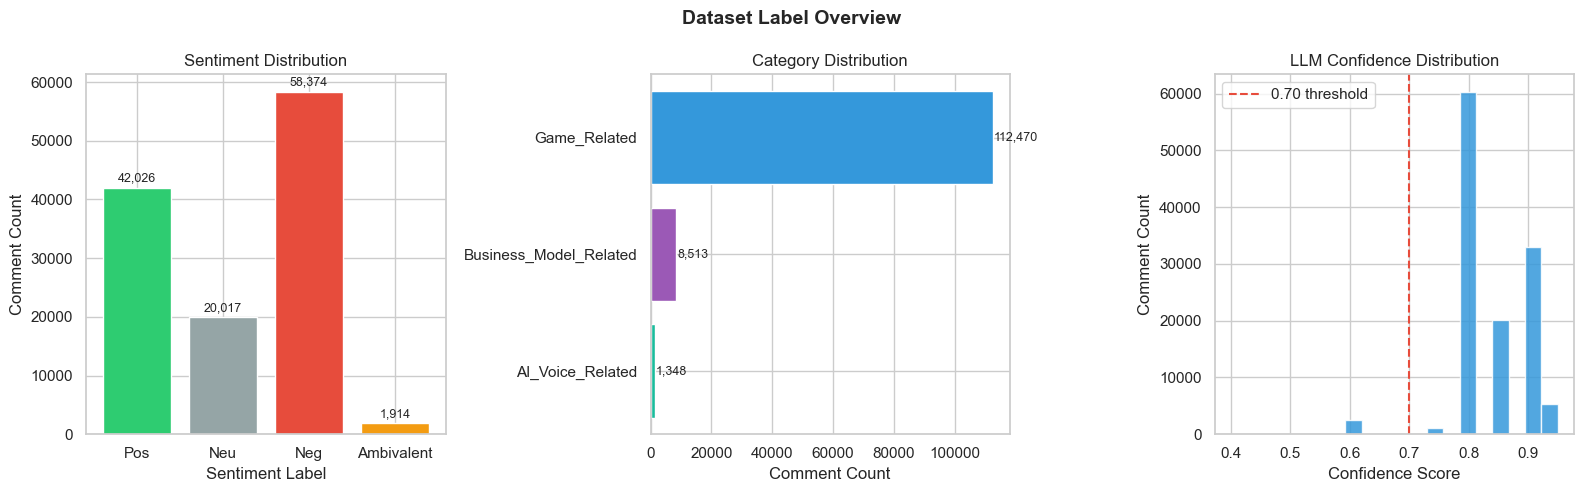

Saved → figures/05_dataset_label_overview.png


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Label Overview", fontsize=14, fontweight='bold')

SENT_ORDER = ['Pos', 'Neu', 'Neg', 'Ambivalent']
SENT_COLORS = {'Pos': '#2ecc71', 'Neu': '#95a5a6', 'Neg': '#e74c3c', 'Ambivalent': '#f39c12'}
CAT_COLORS  = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22']

# --- Sentiment bar ---
ax = axes[0]
order = [s for s in SENT_ORDER if s in sent_counts.index]
colors = [SENT_COLORS[s] for s in order]
ax.bar(order, sent_counts[order], color=colors, edgecolor='white')
for bar, val in zip(ax.patches, sent_counts[order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Sentiment Distribution')
ax.set_ylabel('Comment Count')
ax.set_xlabel('Sentiment Label')

# --- Category bar ---
ax = axes[1]
cats = cat_counts.index.tolist()
ax.barh(cats, cat_counts[cats], color=CAT_COLORS, edgecolor='white')
for bar, val in zip(ax.patches, cat_counts[cats]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Category Distribution')
ax.set_xlabel('Comment Count')
ax.invert_yaxis()

# --- LLM Confidence histogram ---
ax = axes[2]
ax.hist(df['confidence'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.70, color='#e74c3c', linewidth=1.5, linestyle='--', label='0.70 threshold')
ax.set_title('LLM Confidence Distribution')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Comment Count')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_dataset_label_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/05_dataset_label_overview.png")

---
## Section 4.2 — Event Detection

In [46]:
# Spike days already flagged via z-score in your wrangling notebook
spike_days = df[df['is_spike'] == True].groupby(
    df['comment_date'].dt.date
).agg(
    volume=('comment_id', 'count'),
    z_score=('z_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})

spike_days = spike_days.sort_values('date').reset_index(drop=True)

# Cluster spikes that are within 3 days of each other into one event
CLUSTER_GAP_DAYS = 3
spike_days['date'] = pd.to_datetime(spike_days['date'])

clusters = []
current_cluster = [spike_days.iloc[0]]
for i in range(1, len(spike_days)):
    row = spike_days.iloc[i]
    if (row['date'] - current_cluster[-1]['date']).days <= CLUSTER_GAP_DAYS:
        current_cluster.append(row)
    else:
        clusters.append(current_cluster)
        current_cluster = [row]
clusters.append(current_cluster)

# Pick the peak day within each cluster as the event anchor
events_detected = []
for cluster in clusters:
    cluster_df = pd.DataFrame(cluster)
    peak_row = cluster_df.loc[cluster_df['volume'].idxmax()]
    events_detected.append({
        'event_date': peak_row['date'].date(),
        'peak_volume': int(peak_row['volume']),
        'mean_z_score': round(cluster_df['z_score'].mean(), 2),
        'cluster_days': len(cluster)
    })

events_df = pd.DataFrame(events_detected).sort_values('peak_volume', ascending=False)

print(f"Total spike days detected:   {len(spike_days)}")
print(f"Clustered into events:       {len(events_df)}")
print("\nTop events by volume (fill in 'event_label' column manually below):")
print(events_df.to_string(index=False))

Total spike days detected:   57
Clustered into events:       33

Top events by volume (fill in 'event_label' column manually below):
event_date  peak_volume  mean_z_score  cluster_days
2026-02-24         5115          3.16             3
2026-02-15         3051          2.80             1
2026-01-16         1778          3.86             2
2024-11-12         1736          5.20             1
2026-01-11         1469          2.97             1
2025-11-30          677          4.08             3
2024-08-20          340          5.26             1
2022-01-22          272          3.93             2
2023-05-21          253          3.12             1
2024-10-23          228          4.51             2
2023-05-16          200          3.79             2
2025-12-05          141          3.69             1
2023-04-25          117          5.21             1
2023-01-10           94          4.24             5
2022-07-30           68          3.99             4
2024-07-10           63          5.

In [47]:
# Known events — used directly as anchors regardless of volume spike
KNOWN_EVENTS = {
    '2021-12-09': 'Game Announcement',
    '2023-05-01': 'PvPvE Design Pivot',
    '2025-06-06': 'Business Model Change',
    '2025-10-30': 'Official Game Launch',
    '2025-11-12': 'AI Voice Acting News',
    '2025-11-13': 'North Line Update',
    '2026-03-15': 'AI Voice Replacement',
}

# Ensure datetime once
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

confirmed_events = pd.DataFrame([
    {'event_date': pd.to_datetime(date), 'event_label': label}
    for date, label in KNOWN_EVENTS.items()
])

def get_peak_after(d):
    # Filter to only future (or same-day) events
    df = events_df[events_df['event_date'] >= d]

    if df.empty:
        return None

    # Find closest future date
    time_deltas = df['event_date'] - d
    idx = time_deltas.idxmin()

    # Enforce 30-day window
    if time_deltas.loc[idx].days <= 30:
        return df.loc[idx, 'peak_volume']

    return None

# Apply function
confirmed_events['peak_volume'] = confirmed_events['event_date'].apply(get_peak_after)

print(confirmed_events[['event_date', 'event_label', 'peak_volume']].to_string(index=False))

event_date           event_label  peak_volume
2021-12-09     Game Announcement          NaN
2023-05-01    PvPvE Design Pivot        200.0
2025-06-06 Business Model Change          NaN
2025-10-30  Official Game Launch          NaN
2025-11-12  AI Voice Acting News        677.0
2025-11-13     North Line Update        677.0
2026-03-15  AI Voice Replacement          NaN


In [48]:
# Map specific event labels to broader categories for the taxonomy chart
EVENT_CATEGORIES = {
    'Game Announcement':     'Game_Related',
    'PvPvE Design Pivot':    'Business_Model_Related',
    'Business Model Change': 'Business_Model_Related',
    'Official Game Launch':  'Game_Related',
    'AI Voice Acting News':  'AI_Voice_Related',
    'North Line Update':     'Game_Related',
    'AI Voice Replacement':  'AI_Voice_Related',
}

confirmed_events['category'] = confirmed_events['event_label'].map(EVENT_CATEGORIES)

# Chart by category
label_counts = confirmed_events['category'].value_counts()

TAXONOMY_COLORS = {
    'Game_Related':            '#3498db',
    'Business_Model_Related':  '#e67e22',
    'AI_Voice_Related':        '#9b59b6',
}

---
## Section 4.3 — Temporal Sentiment Windows

In [49]:
# =============================================================================
# Pre-event: 7 days before | Event: ±2 days | Post-event: 7 days after
# LLM labels used as ground truth throughout
# =============================================================================
PRE_DAYS     = 7
POST_DAYS    = 7
EVENT_WINDOW = 2  # ±2 days around event anchor

def classify_window(comment_date, event_date):
    delta = (comment_date - event_date).days
    if -PRE_DAYS <= delta < -EVENT_WINDOW:
        return 'Pre-Event'
    elif -EVENT_WINDOW <= delta <= EVENT_WINDOW:
        return 'Event'
    elif EVENT_WINDOW < delta <= POST_DAYS:
        return 'Post-Event'
    return None

window_records = []
for _, event_row in confirmed_events.iterrows():
    edate    = event_row['event_date']
    elabel   = event_row['event_label']
    ecategory = event_row['category']

    window_start = edate - pd.Timedelta(days=PRE_DAYS)
    window_end   = edate + pd.Timedelta(days=POST_DAYS)

    mask = (df['comment_date'] >= window_start) & (df['comment_date'] <= window_end)
    subset = df[mask].copy()
    subset['window']         = subset['comment_date'].apply(lambda d: classify_window(d, edate))
    subset = subset[subset['window'].notna()]
    subset['event_label']    = elabel
    subset['event_date']     = edate
    subset['event_category'] = ecategory
    window_records.append(subset)

if window_records:
    windows_df = pd.concat(window_records, ignore_index=True)
    print(f"Total windowed comment rows: {len(windows_df):,}")
    print(windows_df.groupby(['event_category', 'event_label', 'window'])['sentiment_score']
          .agg(['count', 'mean']).round(3))
else:
    print("⚠️  No confirmed events yet.")
    windows_df = pd.DataFrame()

Total windowed comment rows: 27,525
                                                         count   mean
event_category         event_label           window                  
AI_Voice_Related       AI Voice Acting News  Event          97  0.072
                                             Post-Event     43  0.233
                                             Pre-Event      89 -0.022
                       AI Voice Replacement  Event           0    NaN
                                             Pre-Event   16622 -0.183
Business_Model_Related Business Model Change Event           8  0.500
                                             Post-Event      1  1.000
                                             Pre-Event      21  0.381
                       PvPvE Design Pivot    Event          87 -0.241
                                             Post-Event     17  0.000
                                             Pre-Event     232 -0.039
Game_Related           Game Announcement     Event    

In [50]:
# Aggregate: mean sentiment score and sentiment ratio per window per event

if not windows_df.empty:
    WINDOW_ORDER = ['Pre-Event', 'Event', 'Post-Event']

    window_agg = windows_df.groupby(['event_label', 'window']).agg(
        comment_count=('comment_id', 'count'),
        mean_sentiment=('sentiment_score', 'mean'),
        pct_pos=('sentiment', lambda x: (x == 'Pos').mean() * 100),
        pct_neg=('sentiment', lambda x: (x == 'Neg').mean() * 100),
        pct_neu=('sentiment', lambda x: (x == 'Neu').mean() * 100),
    ).reset_index()
    window_agg['window'] = pd.Categorical(window_agg['window'], categories=WINDOW_ORDER, ordered=True)
    window_agg = window_agg.sort_values(['event_label', 'window'])

    print("Sentiment by Event × Window:")
    print(window_agg.to_string(index=False))

Sentiment by Event × Window:
          event_label     window  comment_count  mean_sentiment   pct_pos   pct_neg   pct_neu
 AI Voice Acting News  Pre-Event            118       -0.022472 31.355932 33.050847 11.016949
 AI Voice Acting News      Event            122        0.072165 34.426230 28.688525 16.393443
 AI Voice Acting News Post-Event             55        0.232558 43.636364 25.454545  9.090909
 AI Voice Replacement  Pre-Event          24803       -0.182830 21.912672 34.165222 10.938193
 AI Voice Replacement      Event              2             NaN  0.000000  0.000000  0.000000
Business Model Change  Pre-Event             32        0.380952 40.625000 15.625000  9.375000
Business Model Change      Event             11        0.500000 54.545455 18.181818  0.000000
Business Model Change Post-Event              2        1.000000 50.000000  0.000000  0.000000
    Game Announcement      Event            951        0.208272 37.329127 22.502629 11.356467
    Game Announcement Post-Even

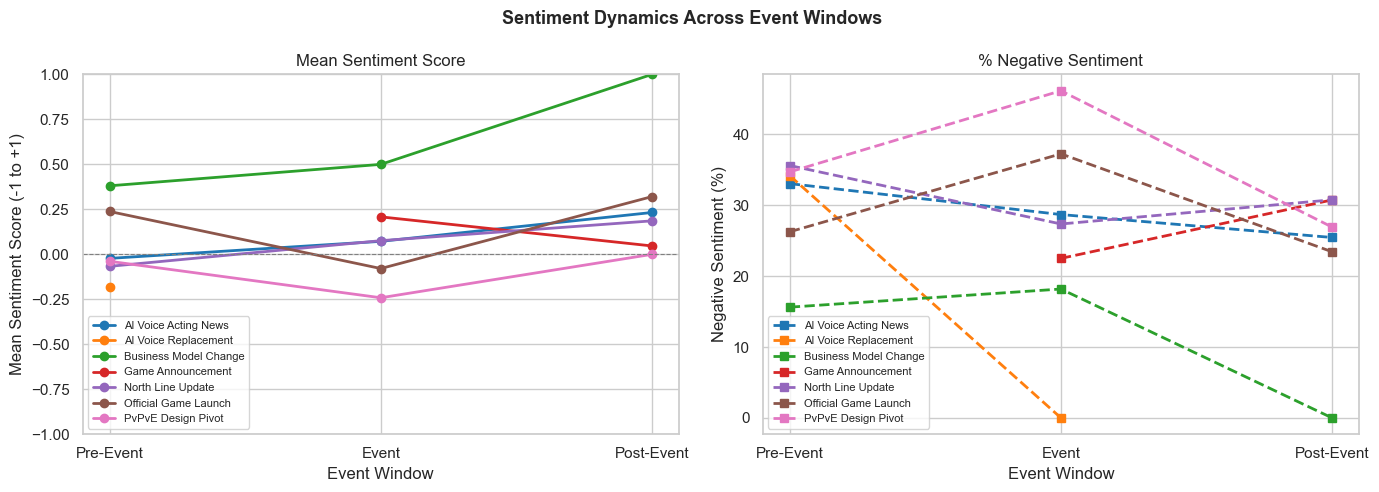

Saved → figures/06_temporal_sentiment_windows.png


In [51]:
# Publication-ready figure: mean sentiment across windows, one line per event type

if not windows_df.empty:
    event_labels = window_agg['event_label'].unique()
    palette = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sentiment Dynamics Across Event Windows', fontsize=13, fontweight='bold')

    # Left: mean sentiment score
    ax = axes[0]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['mean_sentiment'],
                marker='o', label=label, color=palette[i], linewidth=2)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title('Mean Sentiment Score')
    ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=8)
    ax.set_ylim(-1, 1)

    # Right: % Negative sentiment
    ax = axes[1]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['pct_neg'],
                marker='s', label=label, color=palette[i], linewidth=2, linestyle='--')
    ax.set_title('% Negative Sentiment')
    ax.set_ylabel('Negative Sentiment (%)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '06_temporal_sentiment_windows.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → figures/06_temporal_sentiment_windows.png")

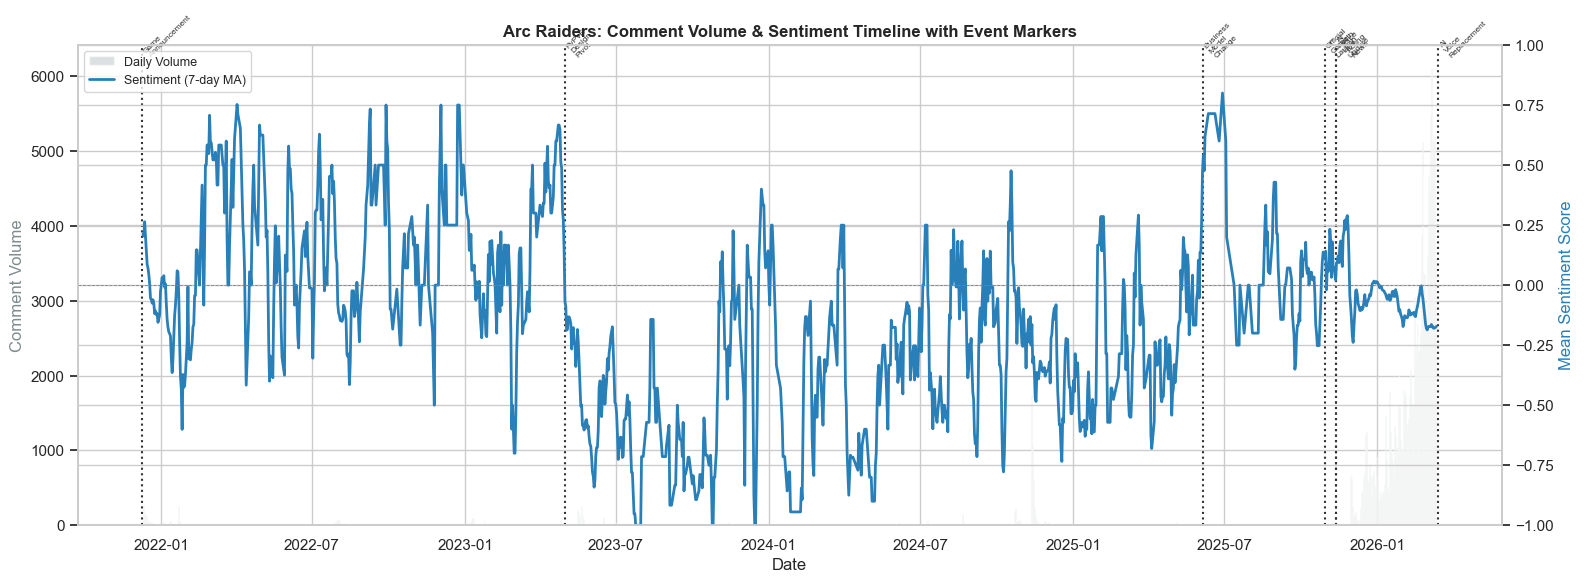

Saved → figures/07_full_timeline_with_events.png


In [52]:
# Full timeline figure: daily sentiment + event markers

daily_all = df.groupby(df['comment_date'].dt.date).agg(
    volume=('comment_id', 'count'),
    mean_sentiment=('sentiment_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})
daily_all['date'] = pd.to_datetime(daily_all['date'])
daily_all['sentiment_ma7'] = daily_all['mean_sentiment'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(daily_all['date'], daily_all['volume'],
        color='#bdc3c7', alpha=0.5, label='Daily Volume', width=1)
ax2.plot(daily_all['date'], daily_all['sentiment_ma7'],
         color='#2980b9', linewidth=2, label='Sentiment (7-day MA)')
ax2.axhline(0, color='grey', linewidth=0.6, linestyle='--')

# Event markers
if not confirmed_events.empty:
    for _, ev in confirmed_events.iterrows():
        color = TAXONOMY_COLORS.get(ev['event_label'], '#333')
        ax1.axvline(ev['event_date'], color=color, linewidth=1.5, linestyle=':')
        ax1.text(ev['event_date'], daily_all['volume'].max() * 1.02,
                 ev['event_label'].replace(' ', '\n'),
                 fontsize=6, color=color, rotation=45, ha='left', va='bottom')

ax1.set_xlabel('Date')
ax1.set_ylabel('Comment Volume', color='#7f8c8d')
ax2.set_ylabel('Mean Sentiment Score', color='#2980b9')
ax2.set_ylim(-1, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Arc Raiders: Comment Volume & Sentiment Timeline with Event Markers',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_full_timeline_with_events.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/07_full_timeline_with_events.png")

---
## Section 4.4 — Per-Category Sentiment Breakdown

In [53]:
CAT_ORDER  = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related']
SENT_ORDER_FULL = ['Pos', 'Neu', 'Neg', 'Ambivalent']

cat_sent = df.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
# Ensure all sentiment columns present
for col in SENT_ORDER_FULL:
    if col not in cat_sent.columns:
        cat_sent[col] = 0
cat_sent = cat_sent[SENT_ORDER_FULL].loc[CAT_ORDER]

cat_sent_pct = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100

print("Sentiment % by Category:")
print(cat_sent_pct.round(2).to_string())

print("\nMean Sentiment Score by Category:")
print(df.groupby('category')['sentiment_score'].agg(['mean', 'std', 'count']).round(3).loc[CAT_ORDER].to_string())

Sentiment % by Category:
sentiment                 Pos    Neu    Neg  Ambivalent
category                                               
Game_Related            36.28  17.06  45.05        1.60
AI_Voice_Related        21.51  22.55  53.49        2.45
Business_Model_Related  10.89   6.14  82.02        0.95

Mean Sentiment Score by Category:
                         mean    std   count
category                                    
Game_Related           -0.089  0.905  110670
AI_Voice_Related       -0.328  0.814    1315
Business_Model_Related -0.718  0.650    8432


/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75077/195728859.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)


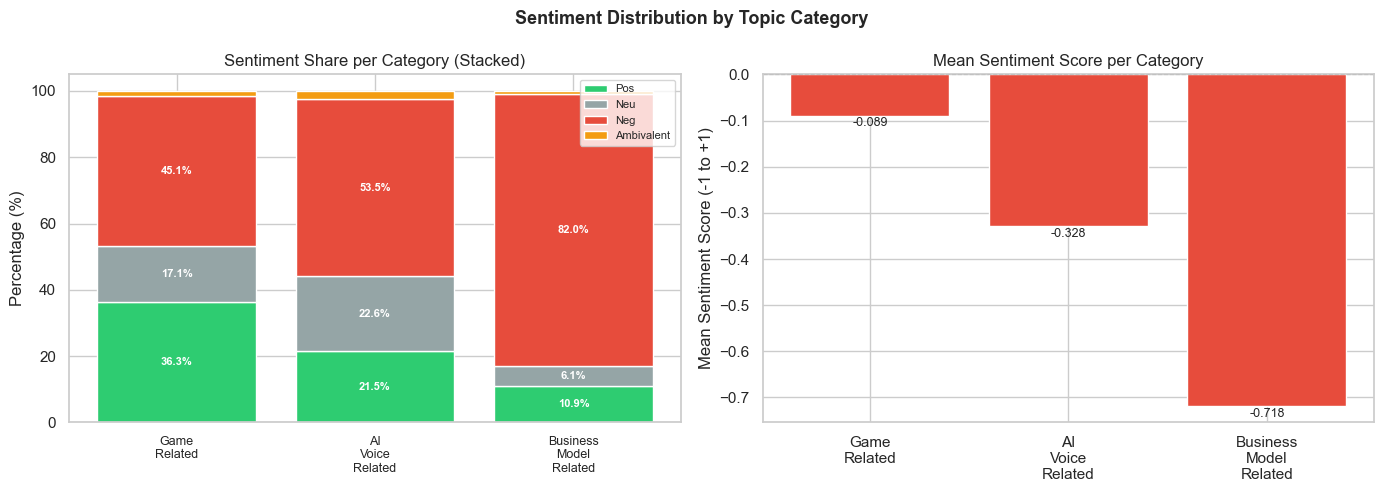

Saved → figures/08_category_sentiment_breakdown.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Distribution by Topic Category', fontsize=13, fontweight='bold')

# Left: stacked bar (% sentiment per category)
ax = axes[0]
bottom = np.zeros(len(CAT_ORDER))
bar_colors = [SENT_COLORS[s] for s in SENT_ORDER_FULL]
for sent, color in zip(SENT_ORDER_FULL, bar_colors):
    vals = cat_sent_pct[sent].values
    bars = ax.bar(CAT_ORDER, vals, bottom=bottom, label=sent, color=color, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 4:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Sentiment Share per Category (Stacked)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)
ax.legend(loc='upper right', fontsize=8)

# Right: mean sentiment score per category
ax = axes[1]
mean_scores = df.groupby('category')['sentiment_score'].mean().loc[CAT_ORDER]
bar_clrs = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mean_scores.values]
ax.bar([c.replace('_', '\n') for c in CAT_ORDER], mean_scores.values,
       color=bar_clrs, edgecolor='white')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Mean Sentiment Score per Category')
ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
for bar, val in zip(ax.patches, mean_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.01 if val >= 0 else -0.03),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_category_sentiment_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/08_category_sentiment_breakdown.png")

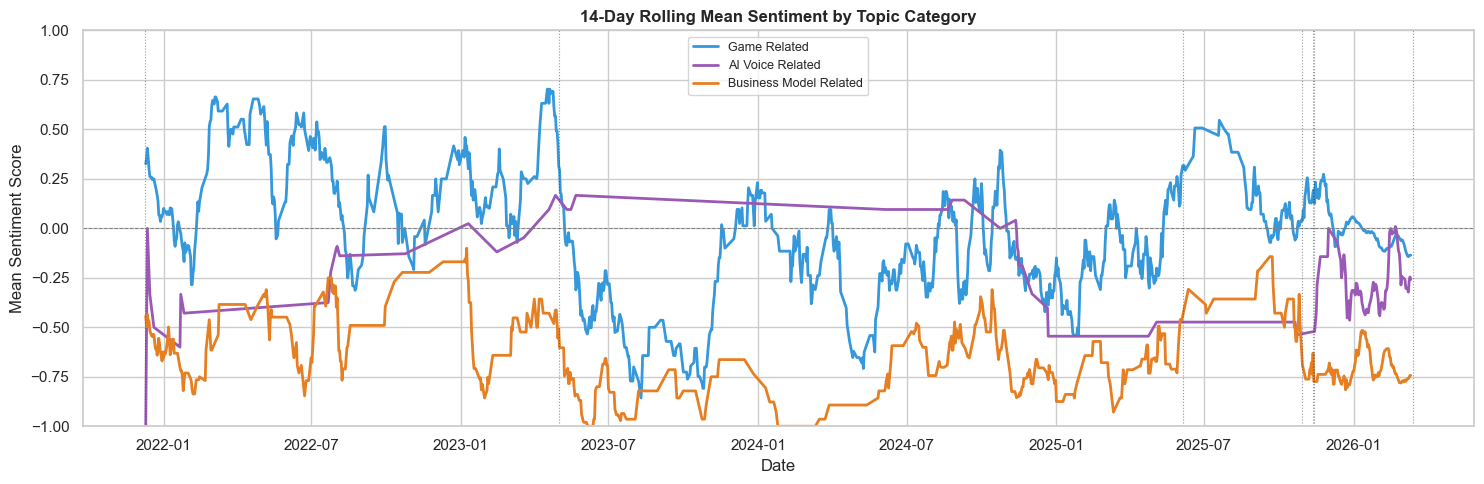

Saved → figures/09_category_sentiment_timeseries.png


In [55]:
# Category sentiment over time — shows AI/Business trending negative
fig, ax = plt.subplots(figsize=(15, 5))

category_colors = {
    'Game_Related':            '#3498db',
    'AI_Voice_Related':        '#9b59b6',
    'Business_Model_Related':  '#e67e22'
}

for cat in CAT_ORDER:
    subset = df[df['category'] == cat].copy()
    daily_cat = subset.groupby(subset['comment_date'].dt.date)['sentiment_score'].mean().reset_index()
    daily_cat.columns = ['date', 'sentiment_ma']
    daily_cat['date'] = pd.to_datetime(daily_cat['date'])
    daily_cat = daily_cat.sort_values('date')
    daily_cat['sentiment_ma'] = daily_cat['sentiment_ma'].rolling(14, min_periods=1).mean()
    ax.plot(daily_cat['date'], daily_cat['sentiment_ma'],
            label=cat.replace('_', ' '), color=category_colors[cat], linewidth=2)

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')

# Add event markers if available
if not confirmed_events.empty:
    for _, ev in confirmed_events.iterrows():
        ax.axvline(ev['event_date'], color='#333', linewidth=0.8, linestyle=':', alpha=0.5)

ax.set_title('14-Day Rolling Mean Sentiment by Topic Category', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sentiment Score')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_category_sentiment_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/09_category_sentiment_timeseries.png")

---
## Section 4.7 — Confidence Analysis

In [56]:
# =============================================================================
# 4.7 CONFIDENCE ANALYSIS
# =============================================================================

# LLM confidence distribution
print("LLM Confidence Summary:")
print(df['confidence'].describe().round(3).to_string())

thresholds = [0.60, 0.70, 0.80, 0.90]
print("\nLLM label retention by confidence threshold:")
print(f"  {'Threshold':<12} {'Retained':>10} {'Pct %':>8}")
for t in thresholds:
    n = (df['confidence'] >= t).sum()
    print(f"  ≥ {t:<10} {n:>10,} {100*n/len(df):>7.1f}%")

LLM Confidence Summary:
count    122331.000
mean          0.837
std           0.060
min           0.400
25%           0.800
50%           0.800
75%           0.900
max           0.950

LLM label retention by confidence threshold:
  Threshold      Retained    Pct %
  ≥ 0.6           122,302    67.0%
  ≥ 0.7           119,829    65.6%
  ≥ 0.8           118,755    65.1%
  ≥ 0.9            38,311    21.0%


---
## Final Summary Report

In [58]:
print("=" * 65)
print(" ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER")
print("=" * 65)

print("\n[Section 3.1 — Dataset]")
print(f"  Total labeled comments:          {len(df):,}")
print(f"  Date range:                      {df['comment_date'].min().date()} – {df['comment_date'].max().date()}")
print(f"  Unique videos:                   {df['video_id'].nunique():,}")
print(f"  Unique commenters:               {df['author_hash'].nunique():,}")

print("\n[Section 3.5 — Confidence-Aware Filtering]")
print(f"  LLM labels with conf ≥ 0.70:     {(df['confidence'] >= 0.70).sum():,} ({100*(df['confidence'] >= 0.70).mean():.1f}%)")

print("\n[Section 4.2 — Event Detection]")
print(f"  Spike days detected:             {len(spike_days)}")
print(f"  Events after clustering:         {len(events_df)}")
print(f"  Manually confirmed events:       {len(confirmed_events)}")

print("\n[Section 4.7 — Confidence]")
print(f"  LLM mean confidence:             {df['confidence'].mean():.3f}")
print(f"  LLM median confidence:           {df['confidence'].median():.3f}")

 ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER

[Section 3.1 — Dataset]
  Total labeled comments:          182,552
  Date range:                      2021-12-10 – 2026-03-13
  Unique videos:                   1,179
  Unique commenters:               104,688

[Section 3.5 — Confidence-Aware Filtering]
  LLM labels with conf ≥ 0.70:     119,829 (65.6%)

[Section 4.2 — Event Detection]
  Spike days detected:             57
  Events after clustering:         33
  Manually confirmed events:       7

[Section 4.7 — Confidence]
  LLM mean confidence:             0.837
  LLM median confidence:           0.800
